# Capstone Project: Predicting High-Value Customers
## Step 3 — Exploratory Data Analysis (EDA)

This notebook explores the **cleaned Customer Shopping Trends Dataset** (3,900 customers)
to understand customer behaviour and surface patterns that distinguish high-value customers
from low-value ones.

**Goals of this EDA:**
1. Understand the overall shape and distributions of the data
2. Explore how spend, loyalty, and subscription relate to customer value
3. Identify the top 2-3 factors that differentiate High vs Low value customers
4. Surface patterns by season, category, and demographics that could inform marketing actions

Each step includes a short comment explaining *what* is being done and *why*.


## 1. Setup & Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, consistent visual style for all charts in this notebook
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("shopping_trends_cleaned.csv")

print("Shape:", df.shape)
df.head()


Shape: (3900, 24)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,purchase_amount_scaled,previous_purchases_scaled,is_subscribed,customer_value_score,customer_value_tier
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Yes,14,Venmo,Fortnightly,0.4125,0.265306,1,0.478482,Medium
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Yes,2,Cash,Fortnightly,0.5500,0.020408,1,0.454643,Medium
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Yes,23,Credit Card,Weekly,0.6625,0.448980,1,0.655268,High
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Yes,49,PayPal,Weekly,0.8750,0.979592,1,0.936607,High
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Yes,31,PayPal,Annually,0.3625,0.612245,1,0.577411,High


## 3. Overall Dataset Snapshot

A quick statistical summary of the numeric fields gives us a feel for typical customer
behaviour before we dive into visuals.


In [5]:
df[["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]].describe().round(2)


,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.00,3900.00,3900.00,3900.00
mean,44.07,59.76,3.75,25.35
std,15.21,23.69,0.72,14.45
min,18.00,20.00,2.50,1.00
25%,31.00,39.00,3.10,13.00
50%,44.00,60.00,3.70,25.00
75%,57.00,81.00,4.40,38.00
max,70.00,100.00,5.00,50.00


## 4. Distribution of Key Numeric Features

Histograms show the shape of each variable — are values spread evenly, skewed, or clustered?


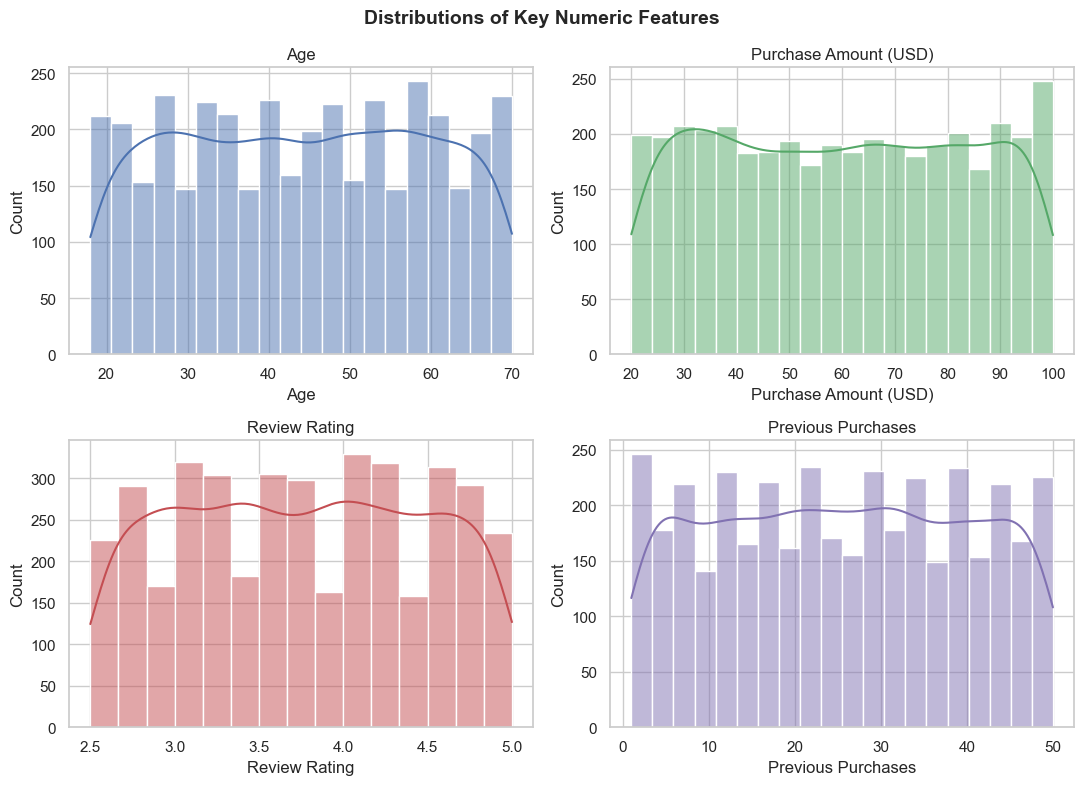

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("Distributions of Key Numeric Features", fontsize=14, fontweight="bold")

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Age")

sns.histplot(df["Purchase Amount (USD)"], bins=20, kde=True, ax=axes[0,1], color="#55A868")
axes[0,1].set_title("Purchase Amount (USD)")

sns.histplot(df["Review Rating"], bins=15, kde=True, ax=axes[1,0], color="#C44E52")
axes[1,0].set_title("Review Rating")

sns.histplot(df["Previous Purchases"], bins=20, kde=True, ax=axes[1,1], color="#8172B2")
axes[1,1].set_title("Previous Purchases")

plt.tight_layout()
plt.show()


**Observation:** Age and Previous Purchases are fairly evenly spread across their range,
Purchase Amount is roughly uniform between \$20-\$100, and Review Ratings cluster between
2.5 and 5 -- consistent with the "clean, capped sample" finding from the wrangling step.


## 5. Customer Value Tier — Class Balance

Before comparing groups, check how many customers fall into each value tier.


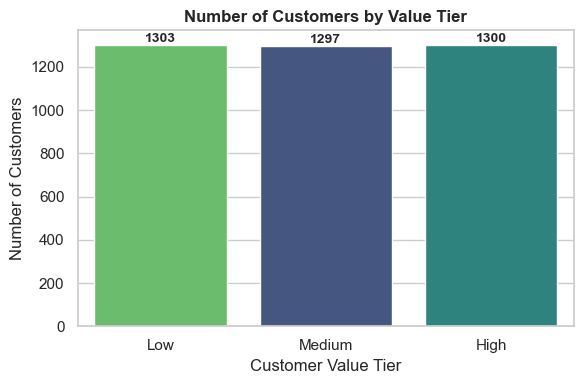

In [8]:
plt.figure(figsize=(6, 4))
order = ["Low", "Medium", "High"]
ax = sns.countplot(data=df, x="customer_value_tier", order=order,
                    hue="customer_value_tier", legend=False, palette="viridis")
ax.set_title("Number of Customers by Value Tier", fontweight="bold")
ax.set_xlabel("Customer Value Tier")
ax.set_ylabel("Number of Customers")

# Add count labels on top of each bar for clarity
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


**Observation:** The terciles produce roughly balanced groups (~1,300 customers each), which is ideal for training a classification model later.

## 6. What Drives Customer Value? Comparing Tiers on Key Features

The problem statement asks for the **top 2-3 contributing factors** behind a customer's
value tier. We compare average Purchase Amount, Previous Purchases, and Subscription Rate,Review rating and Age
across the three tiers.


In [10]:
tier_summary = df.groupby("customer_value_tier")[
    ["Purchase Amount (USD)", "Previous Purchases", "is_subscribed", "Review Rating", "Age"]
].mean().round(2)

tier_summary


,Purchase Amount (USD),Previous Purchases,is_subscribed,Review Rating,Age
customer_value_tier,,,,,
High,77.40,34.48,0.52,3.76,44.50
Low,40.35,16.83,0.07,3.74,44.08
Medium,61.59,24.77,0.22,3.76,43.62


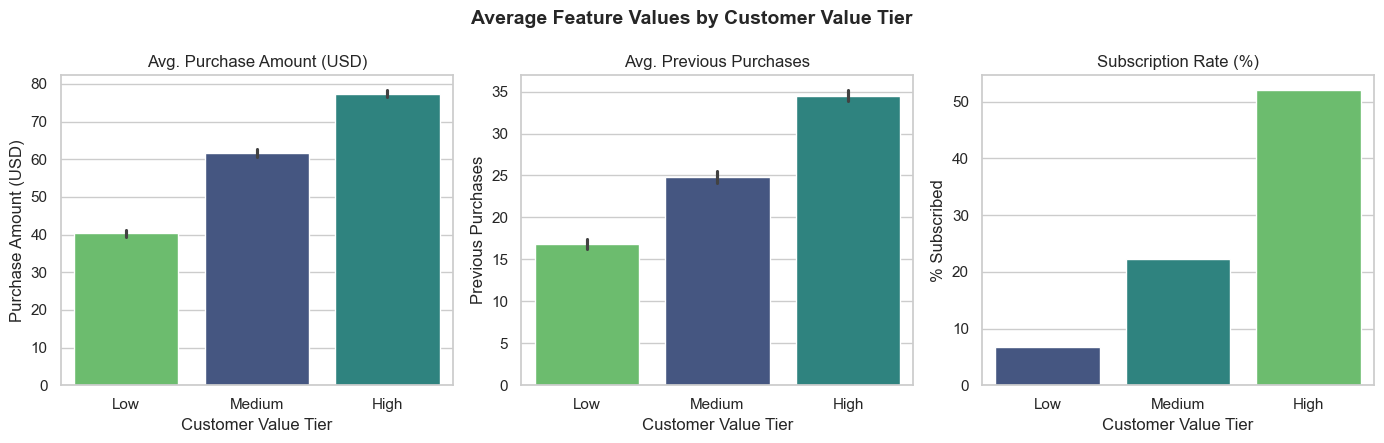

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Average Feature Values by Customer Value Tier", fontsize=14, fontweight="bold")

sns.barplot(data=df, x="customer_value_tier", y="Purchase Amount (USD)", order=order,
            hue="customer_value_tier", legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Avg. Purchase Amount (USD)")

sns.barplot(data=df, x="customer_value_tier", y="Previous Purchases", order=order,
            hue="customer_value_tier", legend=False, ax=axes[1], palette="viridis")
axes[1].set_title("Avg. Previous Purchases")

# Subscription rate as a percentage
sub_rate = df.groupby("customer_value_tier")["is_subscribed"].mean().reindex(order) * 100
sns.barplot(x=sub_rate.index, y=sub_rate.values, hue=sub_rate.index, legend=False, ax=axes[2], palette="viridis")
axes[2].set_title("Subscription Rate (%)")
axes[2].set_ylabel("% Subscribed")

for ax in axes:
    ax.set_xlabel("Customer Value Tier")

plt.tight_layout()
plt.show()


**Top contributing factors (High vs Low tier):**
1. **Purchase Amount** — High-tier customers spend noticeably more per transaction
2. **Previous Purchases** — High-tier customers have a much longer purchase history
3. **Subscription Status** — Nearly all High-tier customers are subscribed, vs almost none in Low

This matches the example given in the problem statement: *"subscribed + buys frequently"*
is a strong High-value signature.


## 7. Seasonal Patterns

The problem statement specifically calls out **seasonal behaviour** as a secondary factor.
We check whether spend or value tier varies by season.


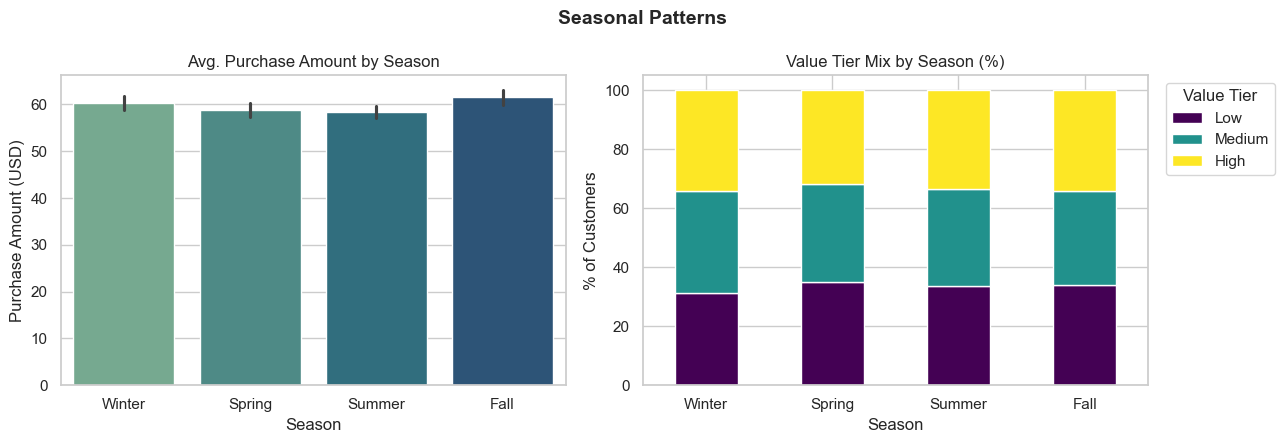

In [16]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Seasonal Patterns", fontsize=14, fontweight="bold")

# Average purchase amount by season
sns.barplot(data=df, x="Season", y="Purchase Amount (USD)", order=season_order,
            hue="Season", legend=False, ax=axes[0], palette="crest")
axes[0].set_title("Avg. Purchase Amount by Season")

# Value tier composition by season (proportions)
season_tier = pd.crosstab(df["Season"], df["customer_value_tier"], normalize="index") * 100
season_tier = season_tier.reindex(season_order)[order]
season_tier.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Value Tier Mix by Season (%)")
axes[1].set_ylabel("% of Customers")
axes[1].legend(title="Value Tier", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


**Observation:** Average spend and the High/Medium/Low mix are fairly similar across seasons -- season alone is a weaker signal than spend, history, or subscription, supporting its role as a *secondary* factor as noted in the problem statement.

## 8. Category & Subscription Breakdown

How does customer value tier relate to product category and subscription status together?


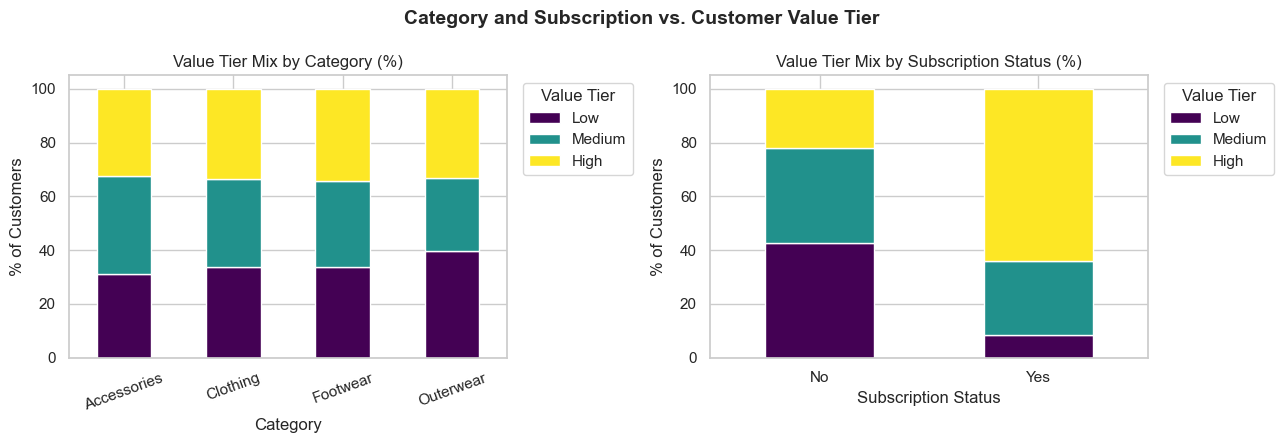

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Category and Subscription vs. Customer Value Tier", fontsize=14, fontweight="bold")

# Value tier mix by product category
cat_tier = pd.crosstab(df["Category"], df["customer_value_tier"], normalize="index") * 100
cat_tier = cat_tier[order]
cat_tier.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Value Tier Mix by Category (%)")
axes[0].set_ylabel("% of Customers")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)
axes[0].legend(title="Value Tier", bbox_to_anchor=(1.02, 1), loc="upper left")

# Subscription status vs value tier
sub_tier = pd.crosstab(df["Subscription Status"], df["customer_value_tier"], normalize="index") * 100
sub_tier = sub_tier[order]
sub_tier.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Value Tier Mix by Subscription Status (%)")
axes[1].set_ylabel("% of Customers")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="Value Tier", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


**Observation:** Product category mix looks broadly similar across tiers (category is not a strong differentiator on its own), but the subscription chart shows a sharp split -- subscribed customers are disproportionately High-value, non-subscribed customers are disproportionately Low-value. This reinforces subscription status as a top driver.

## 9. Correlation Heatmap

A correlation heatmap of the numeric features helps confirm relationships seen in the bar
charts and checks for any unexpected strong correlations (e.g. multicollinearity) before modeling.


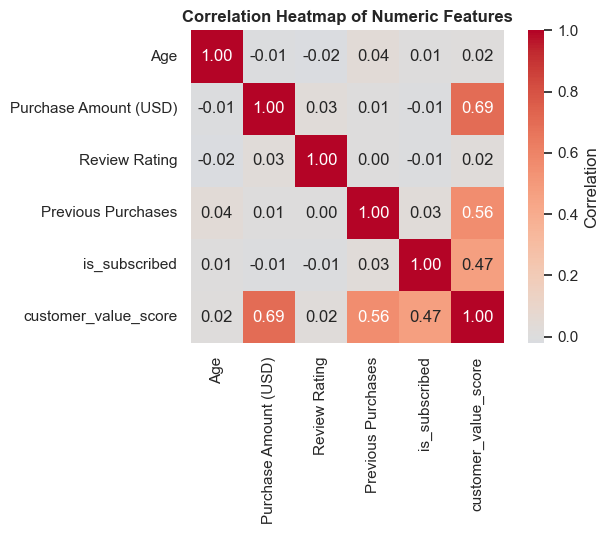

In [18]:
numeric_for_corr = df[[
    "Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases",
    "is_subscribed", "customer_value_score"
]]

plt.figure(figsize=(7, 5.5))
corr = numeric_for_corr.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap of Numeric Features", fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** `customer_value_score` correlates most strongly with `Purchase Amount`,
`Previous Purchases`, and `is_subscribed` (by construction), while `Age` and `Review Rating`
show little to no correlation with value -- suggesting these two features add limited
predictive power on their own and may play a smaller role in the modeling stage.


## 10. Demographics: Gender & Age vs Value Tier

A quick look at whether gender or age group relates to customer value.


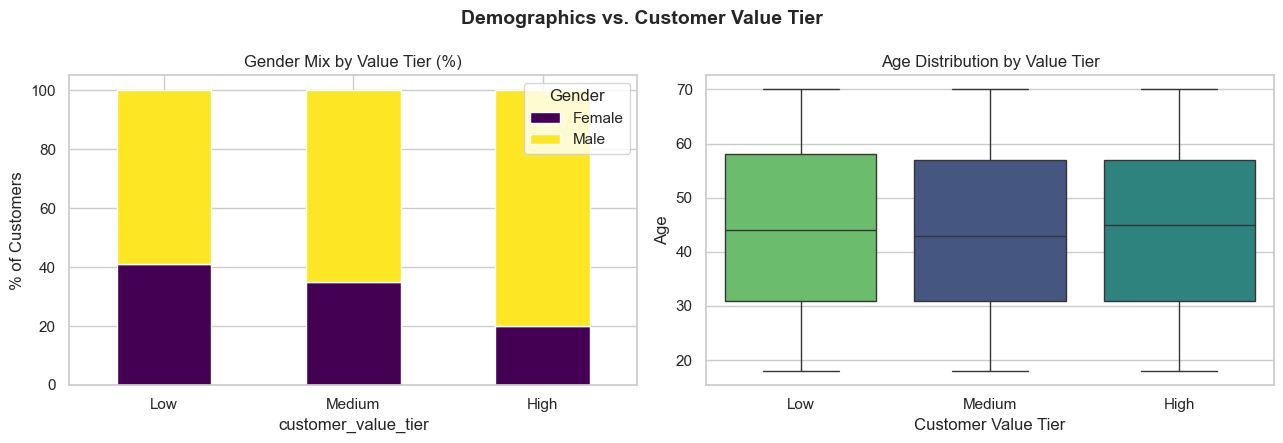

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Demographics vs. Customer Value Tier", fontsize=14, fontweight="bold")

# Gender mix by value tier
gender_tier = pd.crosstab(df["customer_value_tier"], df["Gender"], normalize="index") * 100
gender_tier = gender_tier.reindex(order)
gender_tier.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Gender Mix by Value Tier (%)")
axes[0].set_ylabel("% of Customers")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Gender")

# Age distribution by value tier
sns.boxplot(data=df, x="customer_value_tier", y="Age", order=order,
            hue="customer_value_tier", legend=False, ax=axes[1], palette="viridis")
axes[1].set_title("Age Distribution by Value Tier")
axes[1].set_xlabel("Customer Value Tier")

plt.tight_layout()
plt.show()


**Observation:** Gender mix and the age distribution look very similar across all three value tiers -- demographics alone don't strongly differentiate high-value customers in this dataset, which is useful to know when prioritizing features for the model.

## 11. Summary of EDA Findings

| Area | Key Finding | Implication for Marketing Strategy |
|---|---|---|
| **Subscription Status** | Strongest differentiator — High tier is overwhelmingly subscribed, Low tier overwhelmingly not | Use subscription status as a top predictor; consider subscription-conversion campaigns for Medium/Low tier non-subscribers |
| **Purchase Amount** | High-tier customers spend visibly more per transaction | Reward high spenders with loyalty perks to retain them |
| **Previous Purchases** | High-tier customers have a much longer purchase history | Long-tenure customers are prime candidates for retention offers |
| **Season** | Minor variation in spend/value mix across seasons | Useful as a secondary/contextual factor, not a primary driver |
| **Category, Gender, Age, Review Rating** | Little to no relationship with value tier | Lower priority features for the predictive model |

**Recommended next step:** Build a classification model using `Purchase Amount`,
`Previous Purchases`, and `Subscription Status` as primary features to predict
`customer_value_tier`, then map predictions to recommended actions (retention offer,
conversion nudge, or leave alone) as outlined in the business benefits.
